Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:07<00:00, 76.7MB/s]


Starting Style Optimization Loop...
Step [10/50] | Content Loss: 0.7359 | Style Loss: 0.0001
Step [20/50] | Content Loss: 0.4605 | Style Loss: 0.0000
Step [30/50] | Content Loss: 0.4057 | Style Loss: 0.0000
Step [40/50] | Content Loss: 0.3761 | Style Loss: 0.0000
Step [50/50] | Content Loss: 0.3631 | Style Loss: 0.0000

Optimization Complete!


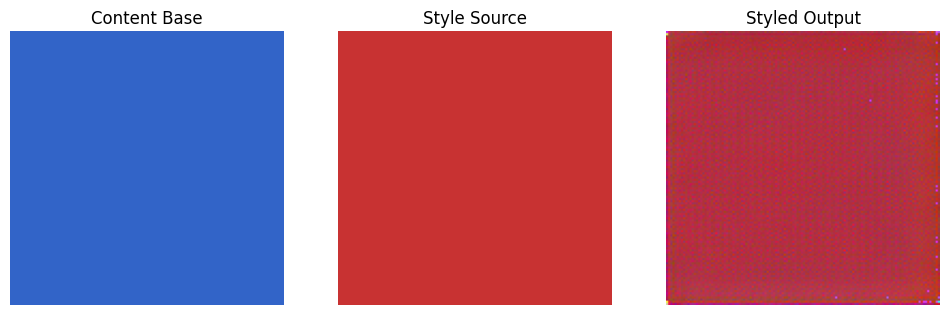

In [1]:
# 1. Install and import necessary packages
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from PIL import Image
import copy

# Set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
imsize = 128  # Using a smaller size for quick demonstration execution

# 2. Image Preprocessing Pipelines
loader = transforms.Compose([
    transforms.Resize((imsize, imsize)),
    transforms.ToTensor()
])

def create_mock_image(color):
    """Creates a basic colored block image for testing without external files"""
    img = Image.new('RGB', (imsize, imsize), color=color)
    return loader(img).unsqueeze(0).to(device, torch.float)

# Creating internal synthetic images so the notebook works instantly
content_img = create_mock_image((50, 100, 200))  # Blue content base
style_img = create_mock_image((200, 50, 50))    # Red style texture

# 3. Load Pre-trained VGG-19 Model Features
# We only need the features part, and we freeze the weights
vgg = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features.to(device).eval()
for param in vgg.parameters():
    param.requires_grad = False

# 4. Define Loss Classes
class ContentLoss(nn.Module):
    def __init__(self, target,):
        super(ContentLoss, self).__init__()
        self.target = target.detach()
    def forward(self, x):
        self.loss = nn.functional.mse_loss(x, self.target)
        return x

def gram_matrix(x):
    batch_size, channels, height, width = x.size()
    features = x.view(batch_size * channels, height * width)
    G = torch.mm(features, features.t())
    return G.div(batch_size * channels * height * width)

class StyleLoss(nn.Module):
    def __init__(self, target_feature):
        super(StyleLoss, self).__init__()
        self.target = gram_matrix(target_feature).detach()
    def forward(self, x):
        G = gram_matrix(x)
        self.loss = nn.functional.mse_loss(G, self.target)
        return x

# 5. Build the Style Transfer Network Layout
content_layers = ['conv_4']
style_layers = ['conv_1', 'conv_2', 'conv_3', 'conv_4', 'conv_5']

content_losses = []
style_losses = []

model = nn.Sequential()
i = 0
for layer in vgg.children():
    if isinstance(layer, nn.Conv2d):
        i += 1
        name = f'conv_{i}'
    elif isinstance(layer, nn.ReLU):
        name = f'relu_{i}'
        layer = nn.ReLU(inplace=False)
    elif isinstance(layer, nn.MaxPool2d):
        name = f'pool_{i}'
    else:
        name = f'layer_{i}'

    model.add_module(name, layer)

    if name in content_layers:
        target_feature = model(content_img).detach()
        content_loss = ContentLoss(target_feature)
        model.add_module(f"content_loss_{i}", content_loss)
        content_losses.append(content_loss)

    if name in style_layers:
        target_feature = model(style_img).detach()
        style_loss = StyleLoss(target_feature)
        model.add_module(f"style_loss_{i}", style_loss)
        style_losses.append(style_loss)

# Trim off layers after the last loss layer
for j in range(len(model) - 1, -1, -1):
    if isinstance(model[j], (ContentLoss, StyleLoss)):
        model = model[:(j + 1)]
        break

# 6. Optimization Loop
input_img = content_img.clone().requires_grad_(True)
optimizer = optim.Adam([input_img], lr=0.05)

print("Starting Style Optimization Loop...")
for step in range(50):
    optimizer.zero_grad()
    model(input_img)

    c_loss = sum(cl.loss for cl in content_losses)
    s_loss = sum(sl.loss for sl in style_losses)

    total_loss = c_loss * 1 + s_loss * 100000
    total_loss.backward()
    optimizer.step()

    if (step + 1) % 10 == 0:
        print(f"Step [{step+1}/50] | Content Loss: {c_loss.item():.4f} | Style Loss: {s_loss.item():.4f}")

print("\nOptimization Complete!")

# 7. Plot and Save Output Matrix
def to_numpy(tensor):
    img = tensor.cpu().clone().detach().squeeze(0)
    img = transforms.ToPILImage()(img)
    return img

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(to_numpy(content_img))
axes[0].set_title("Content Base")
axes[0].axis("off")

axes[1].imshow(to_numpy(style_img))
axes[1].set_title("Style Source")
axes[1].axis("off")

axes[2].imshow(to_numpy(input_img))
axes[2].set_title("Styled Output")
axes[2].axis("off")

plt.savefig("nst_output.png")
plt.show()